In [1]:
import sys
import introns
import importlib
import warnings
import pickle

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from Bio import SeqIO
from Bio.SeqUtils import GC
from termcolor import colored
from sklearn.utils import class_weight
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, precision_recall_fscore_support, multilabel_confusion_matrix, confusion_matrix

importlib.reload(introns)

C:\Users\annaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\base.py:329: UserWarning: Trying to unpickle estimator _BinaryGaussianProcessClassifierLaplace from version 1.0.1 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\annaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\base.py:329: UserWarning: Trying to unpickle estimator GaussianProcessClassifier from version 1.0.1 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  warnings.warn

<module 'introns' from 'c:\\Users\\annaw\\Studia\\eugleny\\ml_solutions_2\\ml_solutions_2\\introns.py'>

In [2]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import LogisticRegression

In [98]:
genome, genes = introns.create('allignmenty_all_2.fasta', 'allignmenty_all_2.gff', 'manual')

for _, gene in genes.items():
    gene.predict_introns()

EL|STRG.5724.1|scaffold_3542:6373-8348 132 562
CCATG ATCCG CCCCC GAAGG
EL|STRG.5724.1|scaffold_3542:6373-8348 637 884
GGACC GCCCG ACACC AGAGG
left 1 EL|STRG.5724.1|scaffold_3542:6373-8348 636 883
CGGAC CGCCC GACAC CAGAG
left 2 EL|STRG.5724.1|scaffold_3542:6373-8348 635 882
CCGGA CCGCC CGACA CCAGA
left 3 EL|STRG.5724.1|scaffold_3542:6373-8348 634 881
ACCGG ACCGC CCGAC ACCAG
EL|STRG.5724.1|scaffold_3542:6373-8348 983 1286
AAACG GTCCT TTCAG GGCGG
left 1 EL|STRG.5724.1|scaffold_3542:6373-8348 982 1285
GAAAC GGTCC CTTCA GGGCG
right 1 EL|STRG.5724.1|scaffold_3542:6373-8348 984 1287
AACGG TCCTG TCAGG GCGGT
EL|STRG.5724.1|scaffold_3542:6373-8348 1444 1916
CCTGG GTTTT TCCAG GTCGG
left 1 EL|STRG.5724.1|scaffold_3542:6373-8348 1443 1915
ACCTG GGTTT TTCCA GGTCG
right 1 EL|STRG.5724.1|scaffold_3542:6373-8348 1445 1917
CTGGG TTTTC CCAGG TCGGG
right 2 EL|STRG.5724.1|scaffold_3542:6373-8348 1446 1918
TGGGT TTTCC CAGGT CGGGA
EH|STRG.10125.1|scaffold_4676:26801-34772 584 1350
TCATG CCCCA CCACG AGCTG
lef

In [99]:
k_labels = ['Intron K', 'Inron K', 'Intron K (EL, EG)', 'Intron K ', 'Exon K', "Intron K (5' partial)"]
nk_labels = ['Intron N', 'Intron N (EH)', 'Intron NK', 'Intron NK ', 'Intron N ', 'Intron NK (polimorfizm)']  
i_labels = ['Intron I', 'Intron I ', 'I', 'Intron P']
label_dict = {}
for i in k_labels:
    label_dict[i] = 'intron_K'
for i in nk_labels:
    label_dict[i] = 'intron_NK'
for i in i_labels:
    label_dict[i] = 'intron_I'
    
from Bio import SeqIO
count = {}

with open('allignmenty_all_2.gb') as gb_file:
    for record in SeqIO.parse(gb_file, "genbank"):
        #print(record)
        gene_name = record.name
        source = 'manual_annotation'
        feature, start, end, score, strand, frame, attribute = '', '', '', '1000', '+', '.', '.'
        gene_start, gene_end = 1000000, 0
        exons = []
        for feature_listed in record.features:
            feature = feature_listed.type
            start, end = int(feature_listed.location.start.position), int(feature_listed.location.end.position)
            try:
                label = feature_listed.qualifiers['label'][0]
            except KeyError as exc:
                print(feature_listed)
                continue
            if label in label_dict.keys():
                label = label_dict[label]
                gene_obj = genes[gene_name]
            try:
                intron_obj = gene_obj.introns_dict[(start, end)]
                intron_obj.add_manual_annotation(label, start, end)
                if label not in count:
                    count[label] = 1
                else:
                    count[label] += 1
            except KeyError:
                pass

print(count)

{'intron_NK': 430, 'intron_K': 368, 'intron_I': 12}


In [100]:
introns_NK, introns_K, introns_I = [], [], []

for gene_name, gene_obj in genes.items():
    for intron in gene_obj.introns:
        intron.add_test_annotation()
        if intron.man_annotation == 'intron_NK':
            introns_NK.append(intron)
        if intron.man_annotation == 'intron_K':
            introns_K.append(intron)
        if intron.man_annotation == 'intron_I':
            introns_I.append(intron)
print('Intron_K', len(introns_K))
print('Intron_NK', len(introns_NK))
print('intron_I', len(introns_I))

Intron_K 368
Intron_NK 430
intron_I 12


In [6]:
def introns_seqs_stats(introns_list, introns_name):
        
    baseY = {'C', 'T'}
    baseR = {'A', 'G'}

    e_y_cnt, i_r_cnt, i_C_cnt, i_A_cnt, i_G_cnt, i_CAG_cnt, i_y_cnt, e_r_cnt = 0, 0, 0, 0, 0, 0, 0, 0
    for intron in introns_list:
        c, a, g = False, False, False
        if intron.prev_exon.sequence[-1] in baseY:
            e_y_cnt += 1
        if intron.sequence[0] in baseR:
            i_r_cnt += 1
        if intron.sequence[3] == 'C' and intron.sequence[-6] == 'G':
            c = True
            i_C_cnt += 1
        if intron.sequence[4] == 'A' and intron.sequence[-7] == 'T':
            a = True
            i_A_cnt += 1
        if intron.sequence[5] == 'G' and intron.sequence[-8] == 'C':
            g = True
            i_G_cnt += 1
        if c and a and g:
            i_CAG_cnt += 1
        if intron.sequence[-1] in baseY:
            i_y_cnt += 1
        if intron.next_exon.sequence[0] in baseR:
            e_r_cnt += 1

    tot = len(introns_list)
    print(introns_name)
    print('total', tot)
    print('eY| i', e_y_cnt/tot)
    print('e |Ri', i_r_cnt/tot)
    print('C-G', i_C_cnt/tot)
    print('A-T', i_A_cnt/tot)
    print('G-C', i_G_cnt/tot)
    print('CAG - CTG', i_CAG_cnt/tot)
    print('iY| e', i_y_cnt/tot)
    print('i |Re', e_r_cnt/tot)
    
    return

In [7]:
introns_seqs_stats(introns_NK, "\tintrons NK")
introns_seqs_stats(introns_K, "\tintrons K")
introns_seqs_stats(introns_I, "\tintrons I")

	introns NK
total 430
eY| i 0.7534883720930232
e |Ri 0.8906976744186047
C-G 0.7209302325581395
A-T 0.5883720930232558
G-C 0.727906976744186
CAG - CTG 0.4441860465116279
iY| e 0.7581395348837209
i |Re 0.9651162790697675
	introns K
total 368
eY| i 0.04891304347826087
e |Ri 1.0
C-G 0.019021739130434784
A-T 0.019021739130434784
G-C 0.07336956521739131
CAG - CTG 0.0
iY| e 0.0
i |Re 0.7853260869565217
	introns I
total 12
eY| i 0.5
e |Ri 1.0
C-G 0.75
A-T 0.75
G-C 0.6666666666666666
CAG - CTG 0.4166666666666667
iY| e 0.25
i |Re 0.9166666666666666


#save introns to file
with open('introns_I_N_from_manual_annotation.fasta', 'w') as f:
    for gene_name, gene_obj in genes.items():
        for intron in gene_obj.introns:
            #intron.add_test_annotation()
            if intron.man_annotation == 'intron_NK':
                seq_to_write = intron.prev_exon.sequence[-5:]+intron.sequence+intron.next_exon.sequence[:5]
                f.write("\n>%s\n%s" %(intron.__str__()+' || intron_NK', seq_to_write))
            if intron.man_annotation == 'intron_K':
                pass
            if intron.man_annotation == 'intron_I':
                seq_to_write = intron.prev_exon.sequence[-5:]+intron.sequence+intron.next_exon.sequence[:5]
                f.write("\n>%s\n%s" %(intron.__str__()+' || intron_I', seq_to_write))

In [8]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
introns_variants, true_classes = [], []

# introny NK - 1
# introny I i inne pozycje - 0

for intron_obj in introns_NK:
    introns_variants.append(introns.compute_intron_characteristics(intron_obj))
    true_classes.append(1)
    for var in intron_obj.variations:
        introns_variants.append(introns.compute_intron_characteristics(var))
        true_classes.append(0)
        
for intron_obj in introns_I:
    introns_variants.append(introns.compute_intron_characteristics(intron_obj))
    true_classes.append(0)
    for var in intron_obj.variations:
        introns_variants.append(introns.compute_intron_characteristics(var))
        true_classes.append(0)

print(len(introns_NK)+len(introns_I))
print(len(introns_variants), len(true_classes))

introns_characteristics = pd.DataFrame(introns_variants,
                                       columns = ['eY| i', 'e |Ri', 'C-G', 'A-T', 'G-C',
                                                  'CAG - CGT', 'iY| e', 'i |Re'])
X_train, X_test, y_train, y_test = train_test_split(introns_characteristics, true_classes,
                                                    test_size=0.3, random_state=420) #, stratify=true_classes)

442
1273 1273


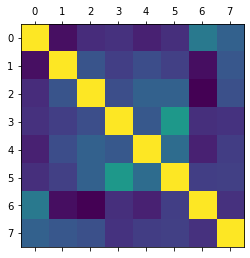

In [10]:
import seaborn as sns
df = pd.DataFrame(introns_characteristics)
df_c = df.corr()
plt.matshow(df_c)
plt.show()

In [57]:
print(introns_characteristics.columns[1],
      "\n", introns_characteristics.columns[2],
      "\n", introns_characteristics.columns[6])

e |Ri 
 C-G 
 iY| e


## Classifier 1 - XGBoost

In [11]:
from xgboost import XGBClassifier


parameters={'booster':['gbtree', 'gblinear', 'dart'],
            'sampling_method':['uniform', 'gradient_based'],
            'importance_type':['gain', 'weight', 'cover', 'total_gain', 'total_cover'],
            'enable_categorical':[True, False],
            'tree_method':['updater','tree_method', 'exact', 'approx', 'hist', 'grow_local_histmaker', 'refresh', 'prune', 'updater', 'tree_method']}



#clf = XGBClassifier()
clf = xgb.XGBClassifier(eval_metric='aucpr', verbosity=0)
clf = GridSearchCV(clf, parameters)
clf.fit(X_train, y_train)
y_predicted = clf.predict(X_test)
print(classification_report(y_test, y_predicted))
print(confusion_matrix(y_test, y_predicted), "\n\n")

C:\Users\annaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\model_selection\_validation.py:372: FitFailedWarning: 
1900 fits failed out of a total of 3000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1200 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\annaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\annaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-pac

              precision    recall  f1-score   support

           0       0.70      0.92      0.80       237
           1       0.73      0.37      0.49       145

    accuracy                           0.71       382
   macro avg       0.72      0.64      0.64       382
weighted avg       0.71      0.71      0.68       382

[[217  20]
 [ 91  54]] 




## Classifier 2 - sklearn Gaussian Process

In [12]:
# uczenie klasyfikatora
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

clf = GaussianProcessClassifier(1.0 * RBF(1.0))
clf.fit(X_train, y_train)
y_test_predicted = clf.predict(X_test)
print(classification_report(y_test, y_test_predicted))


              precision    recall  f1-score   support

           0       0.79      0.89      0.84       237
           1       0.77      0.61      0.68       145

    accuracy                           0.78       382
   macro avg       0.78      0.75      0.76       382
weighted avg       0.78      0.78      0.78       382



## Classifiers 3+ - sklearn multiple types

In [13]:
names = [
    "Ridge Classifier",
    "Linear Prediction",
    "Logistic Regression",
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

classifiers = [
    RidgeClassifier(),
    SGDClassifier(loss='log'),
    LogisticRegression(random_state=0),
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, probability=True),
    SVC(gamma=2, C=1, probability=True),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

In [14]:
for name, clf in list(zip(names, classifiers)):
    clf.fit(X_train, y_train)
    y_predicted = clf.predict(X_test)
    print(name, "\n", classification_report(y_test, y_predicted))
    print(confusion_matrix(y_test, y_predicted), "\n\n")

Ridge Classifier 
               precision    recall  f1-score   support

           0       0.79      0.89      0.84       237
           1       0.77      0.61      0.68       145

    accuracy                           0.78       382
   macro avg       0.78      0.75      0.76       382
weighted avg       0.78      0.78      0.78       382

[[211  26]
 [ 57  88]] 


Linear Prediction 
               precision    recall  f1-score   support

           0       0.71      0.92      0.80       237
           1       0.74      0.39      0.51       145

    accuracy                           0.71       382
   macro avg       0.72      0.65      0.65       382
weighted avg       0.72      0.71      0.69       382

[[217  20]
 [ 89  56]] 


Logistic Regression 
               precision    recall  f1-score   support

           0       0.78      0.90      0.84       237
           1       0.78      0.59      0.67       145

    accuracy                           0.78       382
   macro avg   

Ridge Classifier, Logistic Regression, Gaussian Process, Neural Net, AdaBoost have almost the same statistics.

## I choose the Ridge Regression classifier for now

## checking position finding

In [102]:
correct_primary_pos, correct_variations, correct_full = 0, 0, 0
for intron in introns_NK:
    v1, v2 = False, False
    print(intron.ML_is_nonconventional, [v.ML_is_nonconventional for v in intron.variations])
    if intron.ML_is_nonconventional:
        v1 = True
        correct_primary_pos +=1
    if True not in [v.ML_is_nonconventional for v in intron.variations]:
        v2 = True
        correct_variations += 1
    if v1 and v2:
        correct_full +=1
print((correct_primary_pos, correct_variations, correct_full), len(introns_NK), correct_full/len(introns_NK)*100)
    

True []
False [True, True, False]
True [True]
True [True, True, True, True, True, True, True, True]
True [True, True, False, False, True, True]
False [False, True, False, False]
False [True, True, True]
True [True]
False [False, True, False, False]
True []
True [True, True, False]
True []
True []
True [False, True, False, False, False, False, True, True, True]
True []
True [True, False, True, False, True]
True [True, False, True]
True []
False [True]
True [False, True, True]
True [True, True, True, True]
True []
True [True]
True [True]
True [False, True, True]
True [True, True]
True []
True [True]
True []
True []
True [True]
True [True, True, True, False, True]
True [True, True, True, True, True]
True [True]
False [True, False, True, True, True, True, False, False]
True [True]
True [True]
True [True]
True [True]
True [True, True, False, False, True]
True []
True []
True [False]
True [True, True]
True [True]
True []
True []
False [True, True, False, False, True]
True [True, True, True]


In [59]:
clf = RidgeClassifier()
clf.fit(introns_characteristics, true_classes)

import pickle
filename = '13_07_binary_model.sav'
pickle.dump(clf, open(filename, 'wb'))

## test klasyfikatora

In [61]:
importlib.reload(introns)

genome, genes = introns.create('allignmenty_all.fasta', 'allignmenty_all.gff', 'manual')

C:\Users\annaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\base.py:329: UserWarning:

Trying to unpickle estimator _BinaryGaussianProcessClassifierLaplace from version 1.0.1 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations

C:\Users\annaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\base.py:329: UserWarning:

Trying to unpickle estimator GaussianProcessClassifier from version 1.0.1 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations



EH|STRG.10174.1|scaffold_4704:8343-26110 559 2651
TTCAC AGCAA TACCA GGCAT
EH|STRG.10174.1|scaffold_4704:8343-26110 2760 7160
CCCAG GTGTG CACAG GACGG
left 1 EH|STRG.10174.1|scaffold_4704:8343-26110 2759 7159
GCCCA GGTGT CCACA GGACG
left 2 EH|STRG.10174.1|scaffold_4704:8343-26110 2758 7158
CGCCC AGGTG GCCAC AGGAC
left 3 EH|STRG.10174.1|scaffold_4704:8343-26110 2757 7157
ACGCC CAGGT TGCCA CAGGA
right 1 EH|STRG.10174.1|scaffold_4704:8343-26110 2761 7161
CCAGG TGTGT ACAGG ACGGC
EH|STRG.10174.1|scaffold_4704:8343-26110 7305 7400
GGACG GTGTG CACAG GCTGT
left 1 EH|STRG.10174.1|scaffold_4704:8343-26110 7304 7399
TGGAC GGTGT GCACA GGCTG
right 1 EH|STRG.10174.1|scaffold_4704:8343-26110 7306 7401
GACGG TGTGC ACAGG CTGTC
EH|STRG.10174.1|scaffold_4704:8343-26110 7498 7789
AAATG GTGTG CATAG GAGGC
left 1 EH|STRG.10174.1|scaffold_4704:8343-26110 7497 7788
GAAAT GGTGT TCATA GGAGG
right 1 EH|STRG.10174.1|scaffold_4704:8343-26110 7499 7790
AATGG TGTGC ATAGG AGGCA
EH|STRG.10174.1|scaffold_4704:8343-26110 7

In [63]:
for _, gene in genes.items():
    gene.predict_introns()

In [67]:
for name, gene in list(genes.items())[:3]:
    print(name)
    print(len(gene.introns))
    for intron in gene.introns[:3]:
        print(len(intron.variations), [(v.ML_is_nonconventional, v.ML_nonconv_proba) for v in intron.variations])
    

EH|STRG.10174.1|scaffold_4704:8343-26110
14
0 []
4 [(False, 0.09273113223650853), (True, 0.9952422938091559), (False, 0.005291420475373343), (True, 0.9875046270439043)]
2 [(True, 0.758950914503373), (True, 0.9298350566928093)]
EH|STRG.10174.2|scaffold_4704:8343-26110
14
0 []
4 [(False, 0.09273113223650853), (True, 0.9952422938091559), (False, 0.005291420475373343), (True, 0.9875046270439043)]
2 [(True, 0.758950914503373), (True, 0.9298350566928093)]
EH|STRG.10174.3|scaffold_4704:8343-26110
14
0 []
4 [(False, 0.09273113223650853), (True, 0.9952422938091559), (False, 0.005291420475373343), (True, 0.9875046270439043)]
2 [(True, 0.758950914503373), (True, 0.9298350566928093)]
